# Loading NIX files with ElcheSort results

Contact: Aitor Morales-Gregorio (a.morales-gregorio@matfyz.cuni.cz)

## Dependencies

You will need python-neo and nixio in order to load the data, simply:
```
pip install neo nixio
```
in your python environment (conda, uv, venv...)

Otherwise in this repository we use `numpy` and `matplotlib`.

For advanced data analysis we recomment the `elephant` package (`pip install elephant`).

## Loading

Use a context manager  (`with`) and `neo.NixIO` to load. If not using the context manager remember to close the file or you can risk contamination (plus no one else will be able to read the file if using a shared filesystem).

In [ ]:
import neo
# you do not need to import nixio, but it has to be installed

# Change this path as needed
file = '../data/P3_2023_05_22_spontaneous_spike_sorted/P3_2023_05_22_spontaneous_final0266_spikes.nix'

with neo.NixIO(file, 'ro') as nio:
    block = nio.read_block()

The block object has all the information, it is HDF5 based, so it has a nested structure:

In [69]:
# This should display some information about the block
# in a pure jupyter notebook it might be ALL the data, vscode will smartly compress it
block

Block with [<neo.core.segment.Segment object at 0x7c8f38d65990>] segments
name: 'Spike Sorting Results from ElcheSort - Session P3_2023_05_22_spontaneous_final0266_spikes'
annotations: {'nix_name': 'neo.block.e28be5fa8aaf4d60ab24d87952ad5335',
  'author': 'Aitor Morales-Gregorio',
  'comment': 'Spike sorting data with full metadata',
  'date_of_creation': '2026-02-01',
  'firing_rate_thr': 0.5,
  'waveform_snr_thr': 5,
  'line_noise_50Hz_thr': 0.6,
  'line_noise_60Hz_thr': 0.6,
  'fraction_spikes_during_stim': 0.1}
rec_datetime: datetime.datetime(2023, 5, 23, 13, 36, 49)
# segments (N=[<neo.core.segment.Segment object at 0x7c8f38d65990>])
0: Segment with [<SpikeTrain(array([  2.02656667,   6.50356667,  10.42606667,  10.7883    ,
        10.85103333,  17.8536    ,  21.33556667,  21.84033333,
        21.9752    ,  33.2515    ,  34.8585    ,  38.20123333,
        38.4852    ,  39.2772    ,  41.64596667,  44.00253333,
        46.328     ,  49.28026667,  56.0489    ,  62.1672    ,
        6

The spiketrains are inside the only segment. Usually there is just one segment, but in experiments with multiple pauses in between multiple segments can be there, to distinguish pieces of data from the same recording session but with a pause in between them. Often this happen when there is a data package loss in large recordings, rarely (maybe even never) in the human data.

In [ ]:
# This is a neo.SpikeTrainList object, index it like a normal list
sts = block.segments[0].spiketrains

# Get one unit
st = sts[4]

# This is a dictionary with information that I (Aitor) put in there after sorting 
st.annotations

# Spike times in seconds
st.times

# This are the waveforms of each spike
st.waveforms

# Indexing like a normal list
# Jupyter should display some of the internal information like unit name, annotations and time
sts[4]

SpikeTrain containing 166 spikes with waveforms; units s; datatype float64 
name: 'Ch 13, Unit 4'
annotations: {'nix_name': 'neo.spiketrain.94459be099864c3b892bbb953a906d26',
  'channel_id': 13,
  'new_electrode_id': 36,
  'x': 2400,
  'y': 2800,
  'n_spikes': 166,
  'firing_rate': 1.3837945981993998,
  'waveform_SNR': 5.912525369460324,
  'line_noise_50Hz': -0.10237720716339285,
  'line_noise_60Hz': 0.06722228510811878,
  'n_excluded_waveform_outliers': 0,
  'fraction_spikes_during_stim': 0,
  'session': 'P3_2023_05_22_spontaneous_final0266_spikes',
  'Label': 'Good'}
time: 0.0 s to 119.96 s

The annotations dictionary contains these attributes:

| Attribute | Description |
|:---|:---|
| `nix_name` | Internal object tracker, ignore this |
| `channel_id` | The recording channel number on the electrode array (value from 1 to 96) (i.e. the index+1 of the raw data file) |
| `new_electrode_id` | Remapped electrode identifier |
| `x` | X-coordinate of the electrode position (in µm) |
| `y` | Y-coordinate of the electrode position (in µm) |
| `n_spikes` | Total number of spikes detected on this unit |
| `firing_rate` | Average firing rate in Hz (spikes per second) |
| `waveform_SNR` | Signal-to-noise ratio of the spike waveform — higher values indicate cleaner isolation |
| `line_noise_50Hz` | Contamination from 50 Hz electrical line noise (common in Europe) |
| `line_noise_60Hz` | Contamination from 60 Hz electrical line noise (common in North America) |
| `n_excluded_waveform_outliers` | Number of spike waveforms excluded as outliers during sorting |
| `fraction_spikes_during_stim` | Proportion of spikes during stimulation (0 = none is expected for spontaneous recordings) |
| `session` | Session ID |
| `Label` | Quality label assigned during spike sorting curation ('Good', 'Bad', or 'Stimulation_artifact'), DO NOT TRUST BLINDLY |

### IMPORTANT: Selecting the right units

You do not want to take all the units in the file, those labelled as 'Bad' are usually noise, multiunit or artifacts.

`IMPORTANT` Always check the pdf reports, sometimes units labelled 'Good' can be NOISE or MUA or ARTIFACTS. The reports contain the unit name and are organized by `channel_id`, so it is easy to map back to the data. 

In [ ]:
# Simple list comprehension, normally this is good enough, always double check the data, waveforms, ISIs...
good_sts = [st for st in sts if st.annotations['Label'] == 'Good']

## How to make simple plots of the data

Raster plot:

(20.0, 23.0)

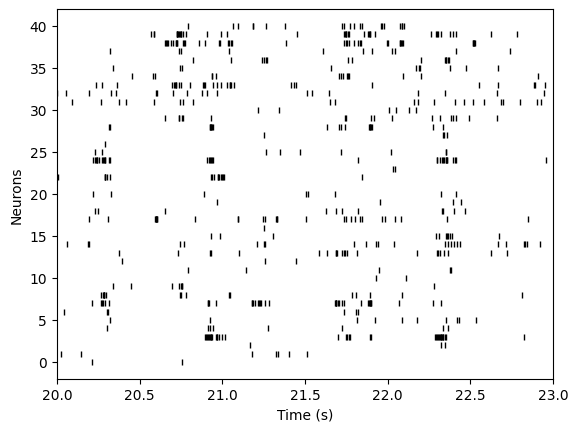

In [42]:
import matplotlib.pyplot as plt
import numpy as np

for i, st in enumerate(good_sts):
    plt.scatter(st, [i]*len(st), marker='|', c='k', s=25, lw=1)

plt.xlabel('Time (s)')
plt.ylabel('Neurons')

# I use this to zoom into a shorter segment (otherwise nothing can be seen)
plt.xlim(20, 23)

# You can also just plot a certain piece of the data by using st.time_slice() or by doing your own cutting of the spike times

Plotting the average waveform over the correct array locations:

Text(0.5, 1.0, "Average waveforms for the 'Good' units")

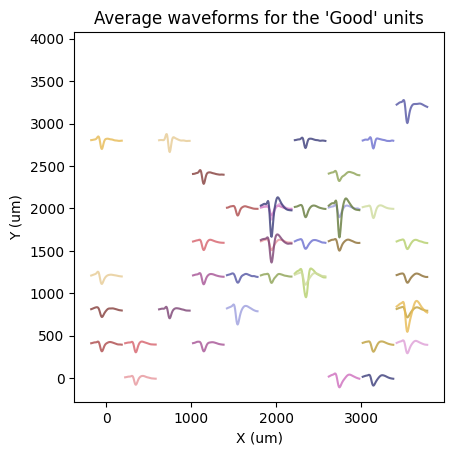

In [ ]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.get_cmap('tab20b').colors)  # This is just for the color cycler

for i, st in enumerate(good_sts):
    
    # Get coordinates
    x = st.annotations['x']
    y = st.annotations['y']

    # Get average waveforms
    waveform_times = np.arange(-30, 31, step=1)  # This is just for convenience, does not mean anything
    average_waveform = st.waveforms.mean(axis=0).magnitude ## This is a Quantity object, so you need to get the magnitude

    # Plot each waveform in location (the multipliers are for aesthetics only)
    plt.plot(6*waveform_times + x, 15*average_waveform + y, lw=1.5, alpha=0.8)

plt.axis('square')
plt.xlabel('X (um)')
plt.ylabel('Y (um)')
plt.title("Average waveforms for the 'Good' units")

# Dealing with Quantities objects

Python-neo uses [Quantities](https://python-quantities.readthedocs.io) under the hood. So for example st.times or st.waveforms are quantities instead of simple numpy arrays. This means that you might get errors complaining that certain units do not match correctly (dimensionless vs uV or so). 

You can always convert quantities arrays to numpy arrays like so
```
numpy_array = quantity_array.magnitude
```

Quantities arrays have convenience functions to rescale units i.e.
```
times.rescale('ms')
```

So the units are always taken into account and unexpected unit mismatches are less likely. 

In general, always convert to numpy before doing any complicated computations, quantities will slow your calcualtions down and possibly trigger some unexpected errors.
